# Trajectory Inference with Diffusion Map and PAGA

Here we use pancreas endocrine development data to demonstrate a Diffusion Map + PAGA workflow: diffusion geometry places cells along a smooth manifold, and PAGA summarizes the coarse-grained branching topology.

## Method background

Following the [Scanpy diffusion pseudotime documentation](https://scanpy.readthedocs.io/en/latest/api/scanpy.tl.dpt.html), the [Scanpy PAGA trajectory tutorial](https://scanpy.readthedocs.io/en/1.10.x/tutorials/trajectories/paga-paul15.html), and the original [PAGA paper](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-019-1663-x), this workflow combines two complementary ideas.

- Diffusion Map emphasizes gradual transitions by embedding cells according to random-walk structure on the neighborhood graph.
- Diffusion Pseudotime (DPT) then orders cells along that manifold once a root region is known.
- PAGA (partition-based graph abstraction) summarizes how coarse cell groups are connected, making the global topology easier to interpret than a dense single-cell graph alone.

This combination is especially helpful when we want both a smooth manifold view and a cluster-level view of the developmental structure.

## Why use the pancreas dataset here?

Pancreatic endocrine development is a compact and interpretable example for diffusion-based trajectory inference. It contains a visible progenitor-to-endocrine progression and multiple endocrine branches, so we can inspect both continuous pseudotime structure and the higher-level topology captured by PAGA.

## Preprocess data

As an example, we apply trajectory inference to pancreas development and then summarize the topology with PAGA.


In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import omicverse as ov
ov.plot_set(font_path='Arial')

%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
adata=ov.datasets.pancreatic_endocrinogenesis()

⚠️ File ./data/endocrinogenesis_day15.h5ad already exists
 Loading data from ./data/endocrinogenesis_day15.h5ad


✅ Successfully loaded: 3696 cells × 27998 genes


In [3]:
adata=ov.pp.preprocess(adata,mode='shiftlog|pearson',n_HVGs=3000,)
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

🔍 [2026-04-28 15:37:34] Running preprocessing in 'cpu' mode...
Begin robust gene identification


    After filtration, 17750/27998 genes are kept.
    Among 17750 genes, 16426 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['Ghrl']



✅ Count Normalization Completed Successfully!
   ✓ Processed: 3,696 cells × 16,426 genes
   ✓ Runtime: 0.08s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 3,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 3,000 highly variable genes out of 16,426 total (18.3%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 0.50 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.2987s                                                 │
│  Shape:    3,696 x 3,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 3696x3000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=50
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (3696, 3000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (14.51s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 14.51s                                                  │
│  Shape:    3,696 x 3,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ scaled|original|X_pca (array, 3696x50)               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


Let us inspect the contribution of single PCs to the total variance in the data. This gives us information about how many PCs we should consider in order to compute the neighborhood relations of cells. In our experience, often a rough estimate of the number of PCs does fine.

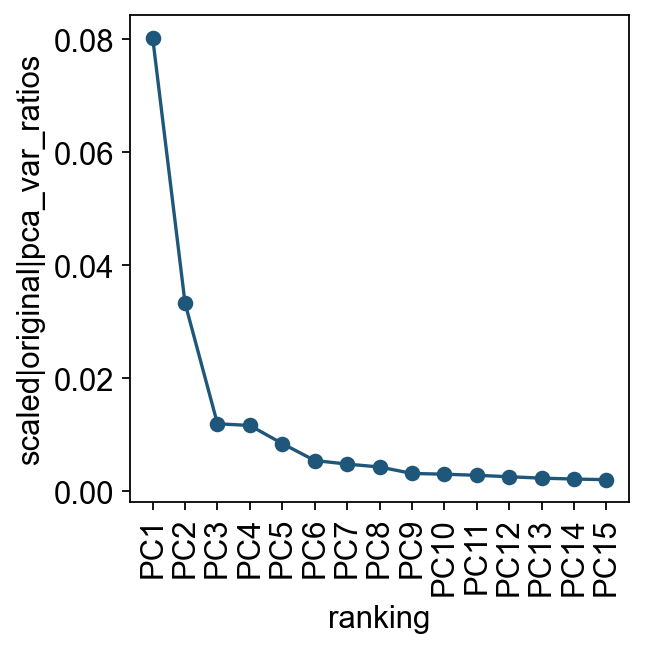

In [4]:
ov.utils.plot_pca_variance_ratio(adata, n_pcs=15)

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


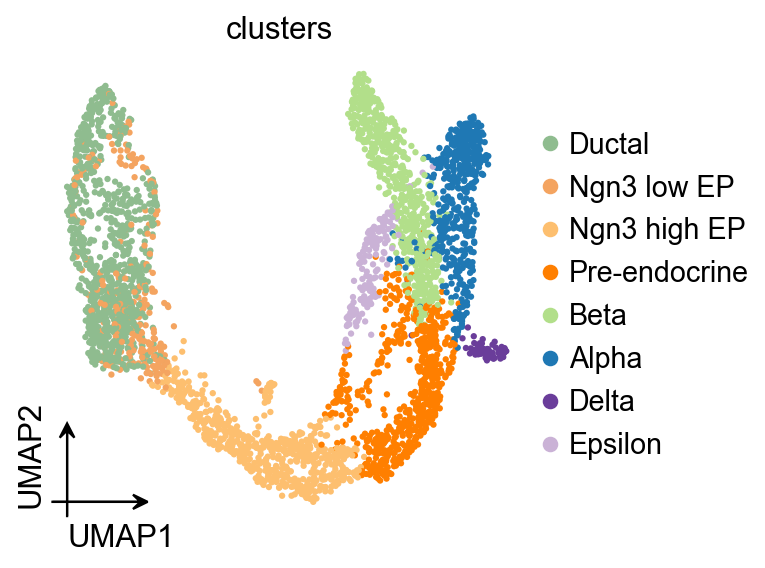

In [5]:
ov.pl.umap(
    adata,
    color='clusters'
)

## Diffusion map

Here, we used `ov.single.TrajInfer` to construct a Trajectory Inference object.

In [6]:
Traj=ov.single.TrajInfer(
    adata,
    basis='X_umap',
    groupby='clusters',
    use_rep='scaled|original|X_pca',
    n_comps=50,
)
Traj.set_origin_cells('Ductal')

In [7]:
Traj.inference(method='diffusion_map')

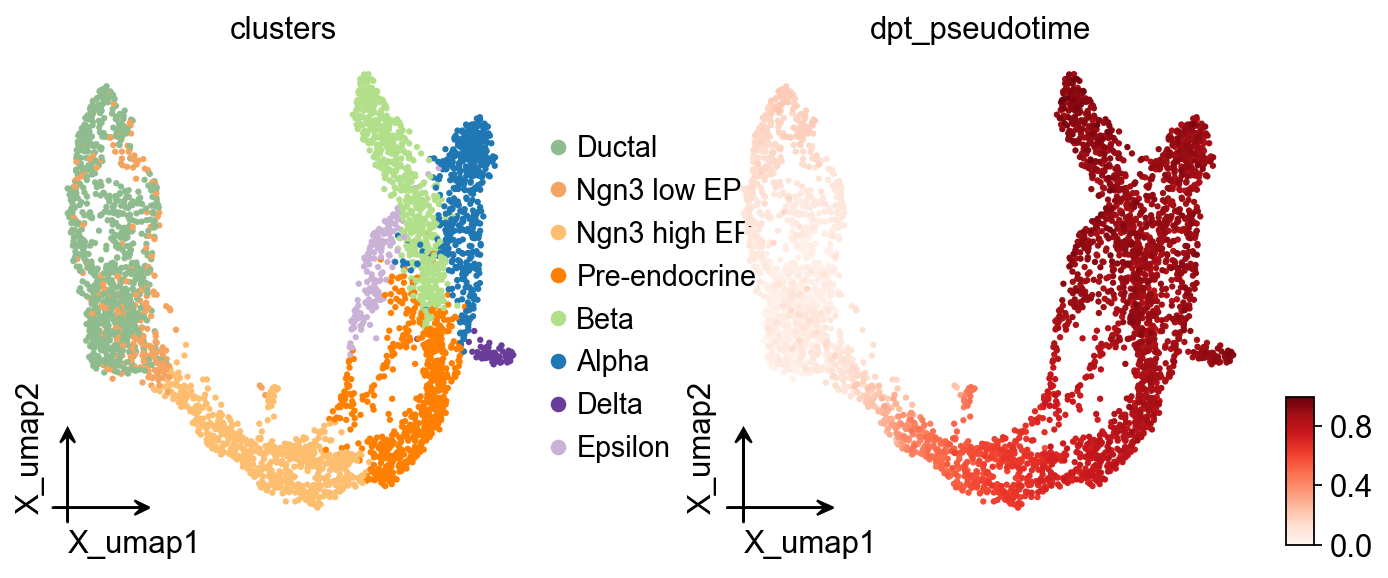

In [8]:
ov.pl.embedding(
    adata,
    basis='X_umap',
    color=['clusters','dpt_pseudotime'],
    frameon='small',
    cmap='Reds'
)

PAGA graph abstraction has benchmarked as top-performing method for trajectory inference. It provides a graph-like map of the data topology with weighted edges corresponding to the connectivity between two clusters. 

Here, PAGA is extended by neighbor directionality.

In [9]:
ov.utils.cal_paga(
    adata,
    use_time_prior='dpt_pseudotime',
    vkey='paga',
    groups='clusters'
)

running PAGA using priors: ['dpt_pseudotime']
    finished
added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


<Axes: title={'center': 'PAGA DPT-graph'}>

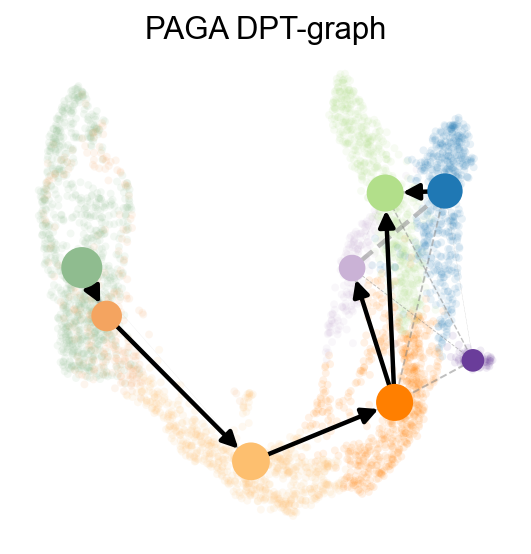

In [10]:
ov.utils.plot_paga(
    adata,basis='umap',
    size=50,
    alpha=.1,
    title='PAGA DPT-graph',
    min_edge_width=2,
    node_size_scale=1.5,
    show=False,
    legend_loc=False
)

## OV trajectory graph overlay

The PAGA graph can also be drawn with the shared `ov.pl.trajectory` interface, so the same visual grammar is available across trajectory methods.

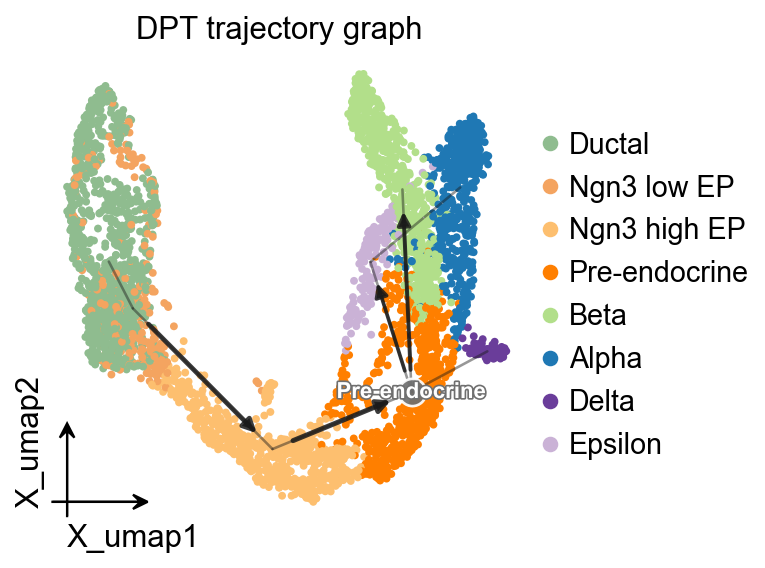

In [11]:
ov.pl.trajectory(
    adata,
    method='paga',
    basis='X_umap',
    groups='clusters',
    color='clusters',
    title='DPT trajectory graph',
)
plt.show()


## OV trajectory overlay

`ov.pl.trajectory_overlay` adds the PAGA backbone to an existing UMAP embedding.

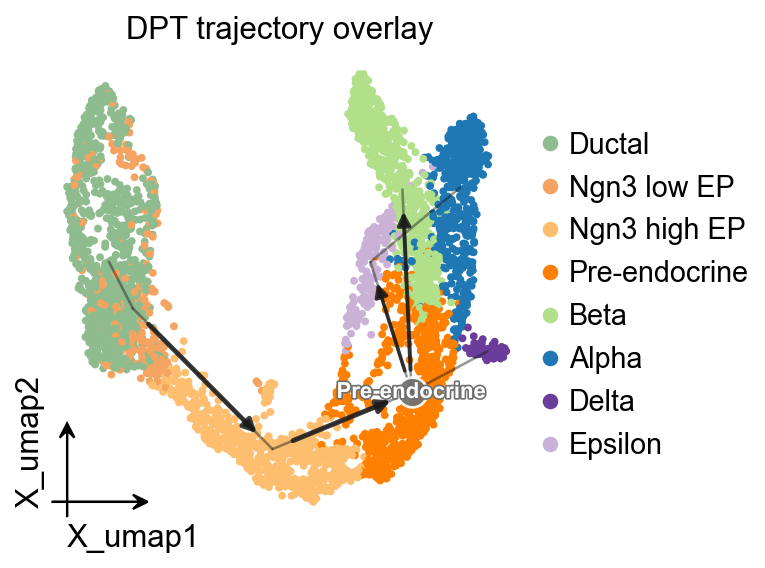

In [12]:
fig, ax = plt.subplots(figsize=(4, 4))
ov.pl.embedding(
    adata,
    basis='X_umap',
    color='clusters',
    ax=ax,
    show=False,
    size=50,
)
ov.pl.trajectory_overlay(
    adata,
    ax=ax,
    method='paga',
    basis='X_umap',
    groups='clusters',
)
ax.set_title('DPT trajectory overlay')
plt.show()


## Branch-aware pseudotime stream plot

`ov.pl.branch_streamplot` uses only a pseudotime vector and cell-state labels, so it can summarize the branch structure inferred by this method as a compact river-style plot. The width of each ribbon shows where a cell state is enriched along pseudotime, while the split centerlines highlight terminal endocrine fates.



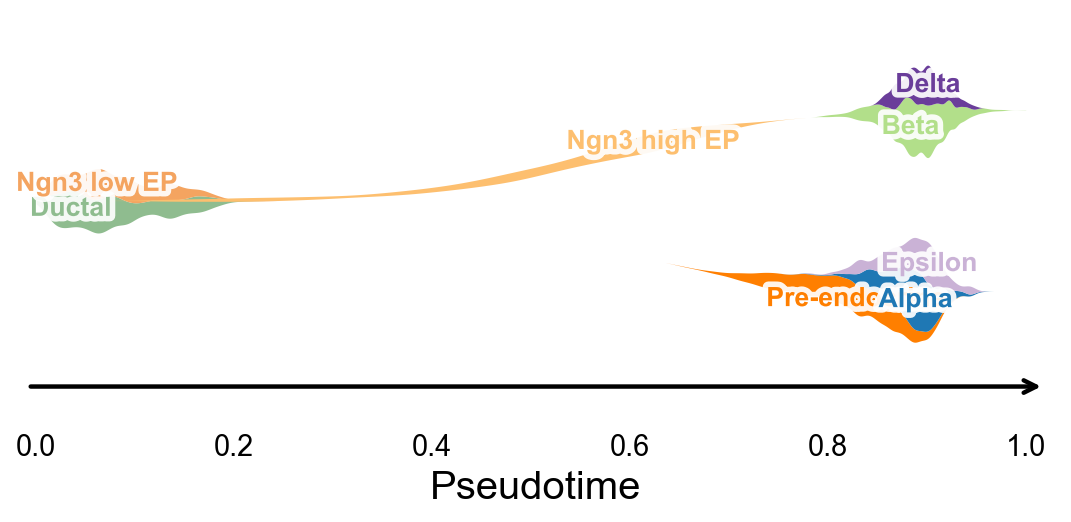

In [13]:
fig, ax = ov.pl.branch_streamplot(
    adata,
    group_key='clusters',
    pseudotime_key='dpt_pseudotime',
    show=False,
)
plt.show()


## Use `dynamic_features` / `dynamic_trends` with DPT pseudotime

`ov.single.dynamic_features` can fit marker trends along `dpt_pseudotime`. We first draw a global marker trend panel with points colored by clusters, then compare late Alpha and Beta programs in a branch-aware panel around the endocrine progenitor stage.

In [14]:
import numpy as np

dpt_trend_genes = ['Sox9', 'Neurog3', 'Fev', 'Gcg', 'Arx', 'Pax4', 'Ins2', 'Pdx1', 'Sst', 'Hhex']

diffusion_dyn = ov.single.dynamic_features(
    adata,
    genes=dpt_trend_genes,
    pseudotime='dpt_pseudotime',
    use_raw=adata.raw is not None,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
    raw_obs_keys=['clusters'],
)



🔍 Dynamic feature analysis:
   Views: 1 | Features: 10
   Pseudotime: dpt_pseudotime
   Stored raw obs keys: ['clusters']
   Expression source: adata.raw
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/10 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 10/10
   ✓ Fitted rows: 2000
   ✓ Raw observations stored: 36960


### Single-line global trends

This view fits one global curve per gene and colors the raw cells by annotation. It is useful for separating the overall pseudotime trend from the cell-state composition that appears around that trend.




🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=False | compare_groups=False


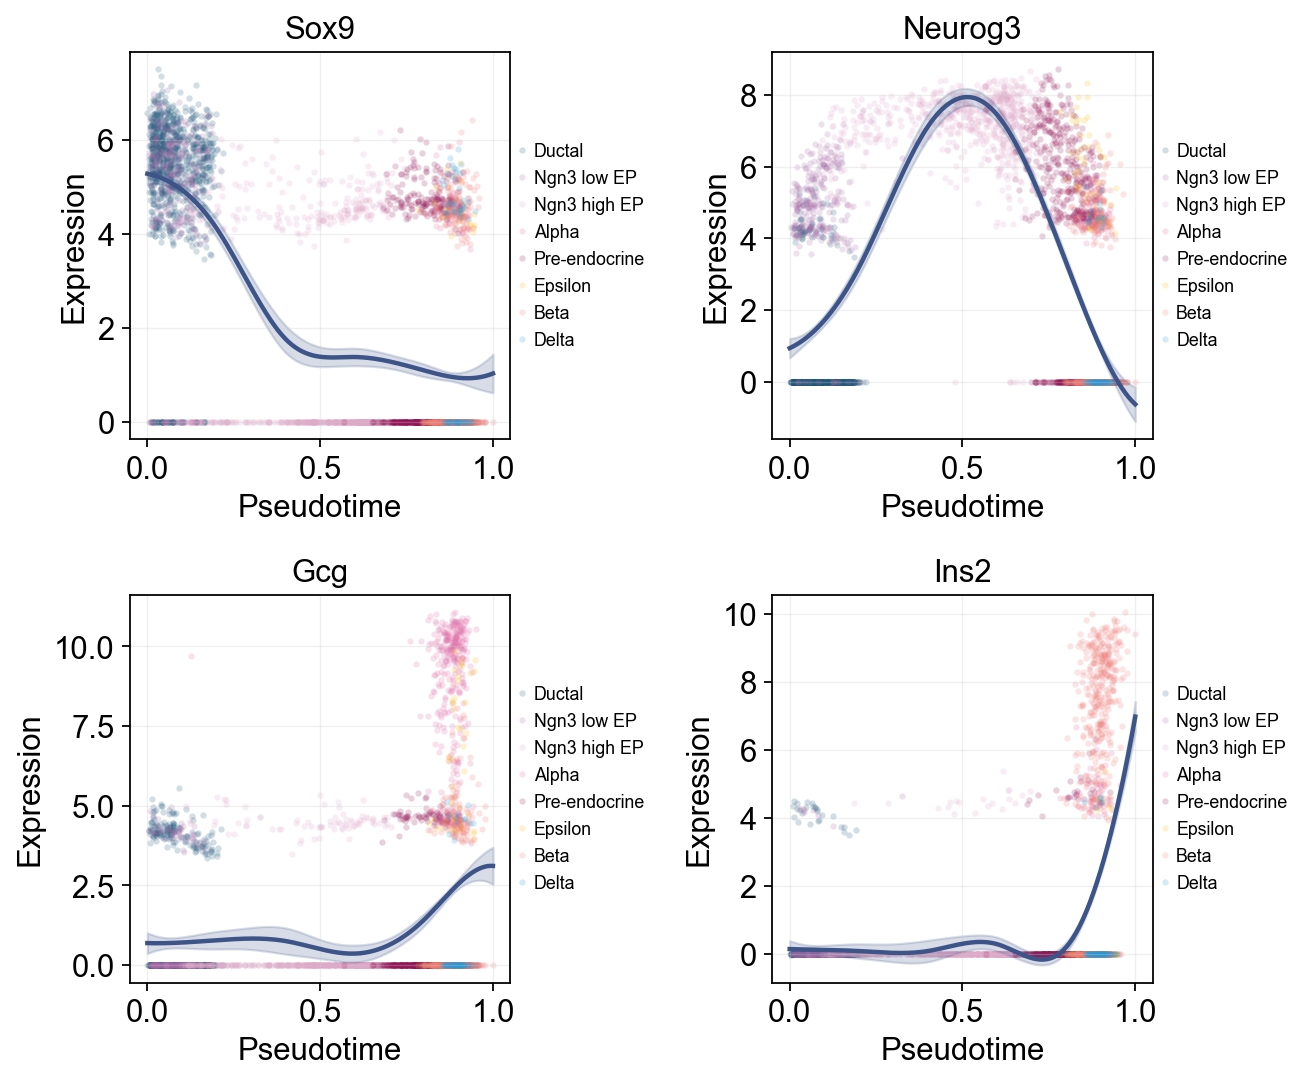

✅ Dynamic trend plotting completed!


In [15]:
ov.pl.dynamic_trends(
    diffusion_dyn,
    genes=['Sox9', 'Neurog3', 'Gcg', 'Ins2'],
    add_point=True,
    point_color_by='clusters',
    figsize=(5, 3.5),
    ncols=2,
    legend_loc='right margin',
    legend_fontsize=8,
)
plt.show()

### Multi-marker trend comparison

Here multiple marker curves are overlaid so their activation timing can be compared directly along the same pseudotime axis.



🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=True | compare_groups=False


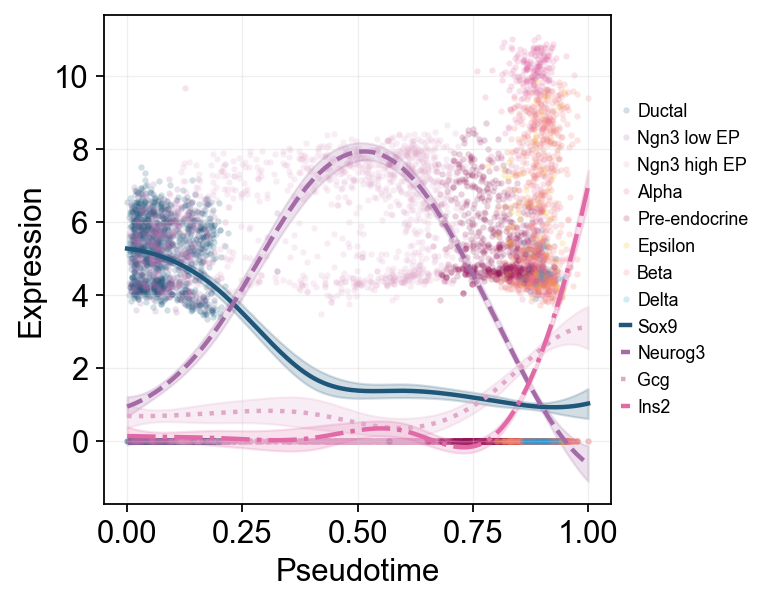

✅ Dynamic trend plotting completed!


In [16]:
ov.pl.dynamic_trends(
    diffusion_dyn,
    genes=['Sox9', 'Neurog3', 'Gcg', 'Ins2'],
    compare_features=True,
    add_point=True,
    point_color_by='clusters',
    line_style_by='features',
    figsize=(6, 4),
    linewidth=2,
    legend_loc='right margin',
    legend_fontsize=8,
)
plt.show()

In [17]:
branch_clusters = ['Alpha', 'Beta']
split_mask = adata.obs['clusters'].astype(str).isin(['Ngn3 high EP', 'Pre-endocrine'])

diffusion_branch_dyn = ov.single.dynamic_features(
    adata,
    genes=['Gcg', 'Ins2', 'Pax4', 'Sox9'],
    pseudotime='dpt_pseudotime',
    groupby='clusters',
    groups=branch_clusters,
    use_raw=adata.raw is not None,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
)
split_time = float(np.nanmedian(adata.obs.loc[split_mask, 'dpt_pseudotime'])) if split_mask.any() else float(np.nanmedian(adata.obs['dpt_pseudotime']))


🔍 Dynamic feature analysis:
   Views: 2 | Features: 4
   Pseudotime: dpt_pseudotime
   Grouping: clusters
   Expression source: adata.raw
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/8 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 8/8
   ✓ Fitted rows: 1600
   ✓ Raw observations stored: 4288



🔍 Dynamic trend plotting:
   Features: 3 | Groups: 2
   compare_features=False | compare_groups=True


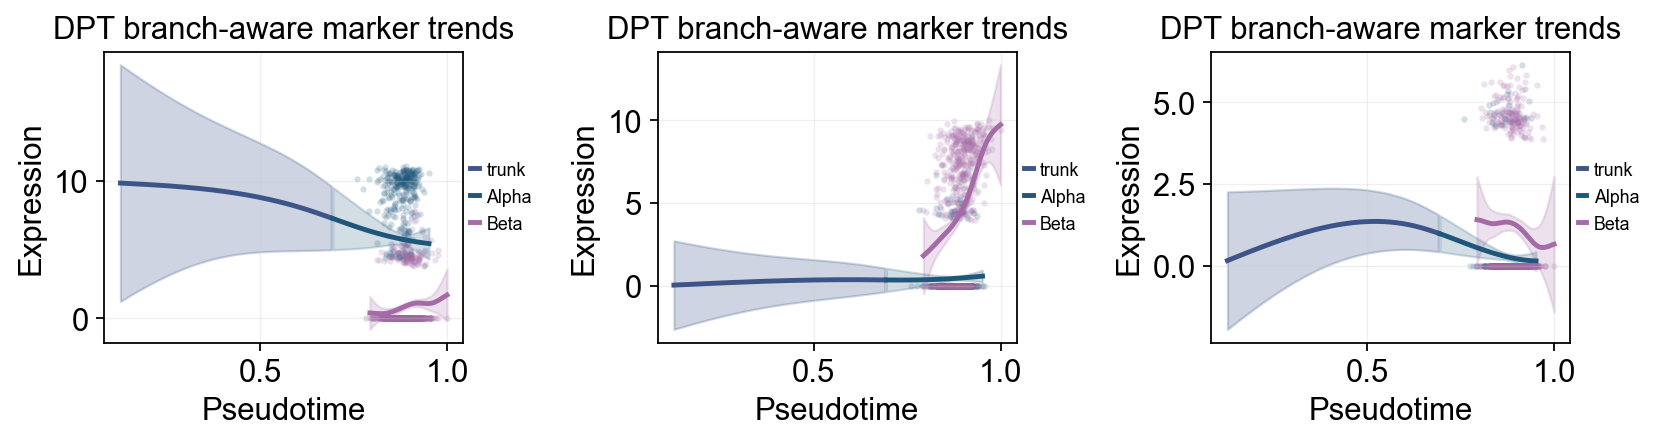

✅ Dynamic trend plotting completed!


In [18]:
ov.pl.dynamic_trends(
    diffusion_branch_dyn,
    genes=['Gcg', 'Ins2', 'Pax4'],
    compare_groups=True,
    split_time=split_time,
    shared_trunk=True,
    add_point=True,
    point_color_by='group',
    figsize=(4.2, 3),
    ncols=3,
    linewidth=2.2,
    legend_loc='right margin',
    legend_fontsize=8,
    title='DPT branch-aware marker trends',
)
plt.show()

## Summarize DPT marker programs with `dynamic_heatmap`

`ov.pl.dynamic_heatmap` summarizes many genes in one pseudotime-ordered panel. Here it checks whether progenitor and endocrine fate markers activate in the same order suggested by DPT pseudotime and the stream plot.



🔍 Dynamic heatmap:
   Candidate features: 10
   Pseudotime: dpt_pseudotime
   Cell annotation: clusters
   use_fitted=True | cell_bins=180 | cmap=RdBu_r



✅ Dynamic heatmap completed!
   ✓ Matrix shape: 10 features × 171 columns


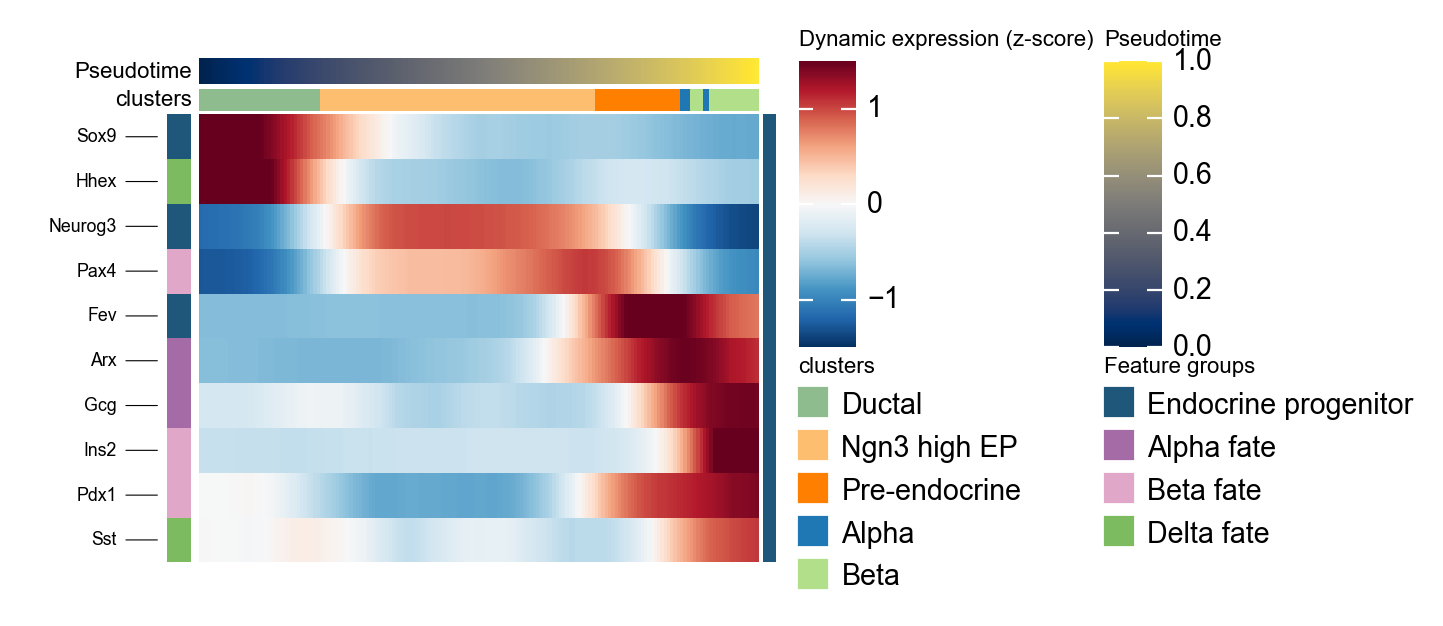

In [19]:
dpt_marker = {
    'Endocrine progenitor': ['Sox9', 'Neurog3', 'Fev'],
    'Alpha fate': ['Gcg', 'Arx'],
    'Beta fate': ['Pax4', 'Ins2', 'Pdx1'],
    'Delta fate': ['Sst', 'Hhex'],
}

g = ov.pl.dynamic_heatmap(
    adata,
    var_names=dpt_marker,
    pseudotime='dpt_pseudotime',
    use_raw=adata.raw is not None,
    use_cell_columns=False,
    cell_annotation='clusters',
    cell_bins=180,
    smooth_window=17,
    fitted_window=31,
    figsize=(5, 4),
    standard_scale='var',
    cmap='RdBu_r',
    use_fitted=True,
    border=False,
    show=False,
)
